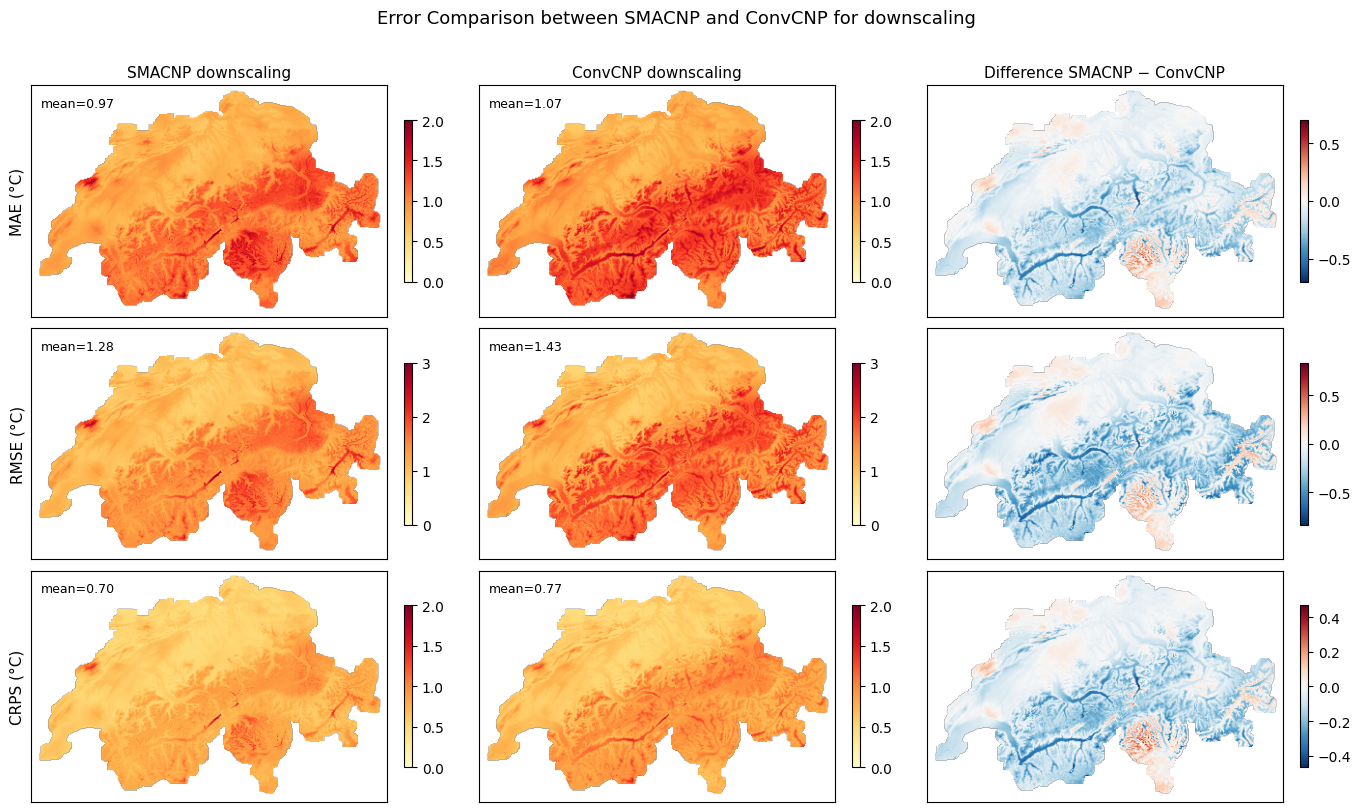

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

MODEL_A_NAME = 'final-2014-30e-5f-smacnp-mean-nll-global'  # SMACNP
MODEL_B_NAME = 'final-2014-30e-5f-6in-mean'                  # ConvCNP

MODEL_DIR = Path('./trained_models')

a = np.load(MODEL_DIR / MODEL_A_NAME / 'perpixel_grids.npz')
b = np.load(MODEL_DIR / MODEL_B_NAME / 'perpixel_grids.npz')

metrics = [
    ('mae',  'MAE (°C)',  'YlOrRd', (0, 2)),
    ('rmse', 'RMSE (°C)', 'YlOrRd', (0, 3)),
    ('crps', 'CRPS (°C)', 'YlOrRd', (0, 2)),
]

col_titles = [
    'SMACNP downscaling',
    'ConvCNP downscaling',
    'Difference SMACNP − ConvCNP',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
fig.suptitle('Error Comparison between SMACNP and ConvCNP for downscaling', fontsize=13, y=1.01)

for row, (key, label, cmap, vrange) in enumerate(metrics):
    va = a[key]
    vb = b[key]
    diff = va - vb

    diff_abs = np.nanmax(np.abs(diff))
    diff_norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-diff_abs, vmax=diff_abs)

    for col, (vals, norm, cmap_use) in enumerate([
        (va,   mcolors.Normalize(*vrange), cmap),
        (vb,   mcolors.Normalize(*vrange), cmap),
        (diff, diff_norm,                   'RdBu_r'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(vals, cmap=cmap_use, norm=norm, origin='lower', aspect='equal')
        plt.colorbar(im, ax=ax, shrink=0.7, fraction=0.035, pad=0.04)
        if row == 0:
            ax.set_title(col_titles[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=11)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        if col < 2:
            ax.text(0.03, 0.95, f'mean={np.nanmean(vals):.2f}', transform=ax.transAxes,
                    fontsize=9, va='top',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig(MODEL_DIR / 'comparison_perpixel_errors.png', dpi=150, bbox_inches='tight')
plt.show()


/home/renku/work/convNPClimate/params.py:98: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (not (not self.SEASONAL_FEATURES and self.SEASONAL_FEATURES_IN_MLP),


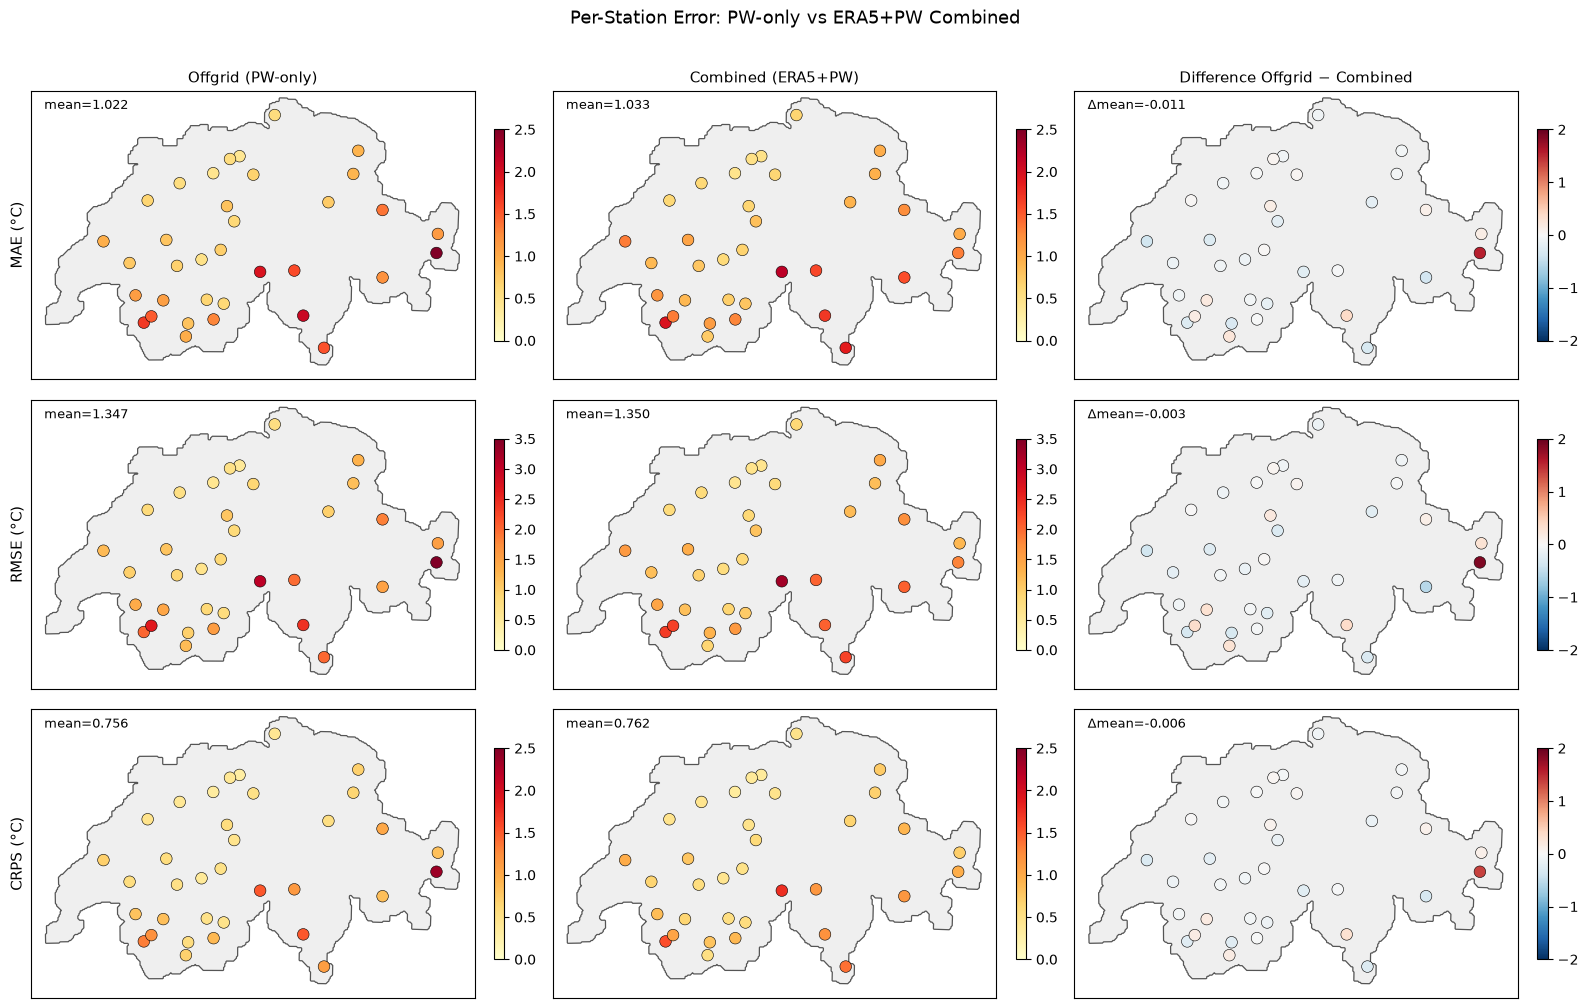

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob
import xarray as xr
from pathlib import Path

import datasets as ds

MODEL_DIR = Path('./trained_models')
MODEL_PW   = 'test-2017-50e-1f-smacnp-pw-mean-v36'   # PW-only
MODEL_COMB = 'test-combined-era5-pw-mean-16'           # ERA5+PW combined

pw   = np.load(MODEL_DIR / MODEL_PW   / 'station_metrics.npz', allow_pickle=True)
comb = np.load(MODEL_DIR / MODEL_COMB / 'station_metrics.npz', allow_pickle=True)

lats = pw['lats']
lons = pw['lons']

_ms_glob = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'
_ms_file = sorted(glob.glob(_ms_glob))[0]
_ms_ds = xr.open_dataset(_ms_file)
_ms_E = _ms_ds['E'].values
_ms_N = _ms_ds['N'].values
_valid = np.isfinite(_ms_ds['TabsD'].isel(time=0).values)

_E_2d, _N_2d = np.meshgrid(_ms_E, _ms_N)
border_lons_2d, border_lats_2d = ds.lv95_to_wgs84(_E_2d, _N_2d)
border_valid_2d = _valid

center_lat = (lats.min() + lats.max()) / 2
geo_aspect = 1.0 / np.cos(np.radians(center_lat))

metrics = [
    ('mae',  'MAE (°C)',  'YlOrRd', (0, 2.5)),
    ('rmse', 'RMSE (°C)', 'YlOrRd', (0, 3.5)),
    ('crps', 'CRPS (°C)', 'YlOrRd', (0, 2.5)),
]

col_titles = ['Offgrid (PW-only)', 'Combined (ERA5+PW)', 'Difference Offgrid − Combined']

def draw_border(ax):
    ax.contourf(border_lons_2d, border_lats_2d, border_valid_2d,
                levels=[0.5, 1.5], colors=['#cccccc'], alpha=0.3, zorder=1)
    ax.contour(border_lons_2d, border_lats_2d, border_valid_2d,
               levels=[0.5], colors='#555555', linewidths=0.9, zorder=2)
    ax.set_aspect(geo_aspect)
    ax.set_facecolor('white')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.suptitle('Per-Station Error: PW-only vs ERA5+PW Combined', fontsize=13, y=1.01)

for row, (key, label, cmap, vrange) in enumerate(metrics):
    va = pw[key]
    vb = comb[key]
    diff = va - vb   # positive = PW worse, negative = Combined worse

    #diff_abs = float(np.nanmax(np.abs(diff)))
    diff_abs = 2
    diff_norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-diff_abs, vmax=diff_abs)

    for col, (vals, norm, cmap_use) in enumerate([
        (va,   mcolors.Normalize(*vrange), cmap),
        (vb,   mcolors.Normalize(*vrange), cmap),
        (diff, diff_norm,                  'RdBu_r'),
    ]):
        ax = axes[row, col]
        draw_border(ax)
        sc = ax.scatter(lons, lats, c=vals, cmap=cmap_use, norm=norm,
                        s=70, edgecolors='k', linewidths=0.4, zorder=3)
        plt.colorbar(sc, ax=ax, shrink=0.7, fraction=0.035, pad=0.04)
        if row == 0:
            ax.set_title(col_titles[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=11)
        if col < 2:
            ax.text(0.03, 0.97, f'mean={np.nanmean(vals):.3f}',
                    transform=ax.transAxes, fontsize=9, va='top',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        else:
            ax.text(0.03, 0.97, f'Δmean={np.nanmean(diff):+.3f}',
                    transform=ax.transAxes, fontsize=9, va='top',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig(MODEL_DIR / 'comparison_station_errors.png', dpi=150, bbox_inches='tight')
plt.show()
